<a href="https://colab.research.google.com/github/Addy48/23FE10CSE00457_MLWine/blob/main/DecisionTree_ML_Lab_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [12]:
from google.colab import files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red (3).csv
Saving winequality-white.csv to winequality-white (3).csv
Saving winequality.names to winequality (3).names


In [26]:
red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')

red['type'] = 'red'
white['type'] = 'white'

df = pd.concat([red, white], ignore_index=True)

In [27]:
df['type'] = df['type'].map({'red': 0, 'white': 1})

In [28]:
X = df.drop('quality', axis=1)
y = df['quality']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Baseline Accuracy (with balanced class_weight):", accuracy_score(y_test, y_pred))

Baseline Accuracy (with balanced class_weight): 0.5778461538461539


In [42]:
param_grid = {
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted', # Changed scoring metric
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20, 30],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1_weighted', verbose=1)

In [43]:
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score: 0.5762014057732026


In [36]:
best_dt = grid.best_estimator_

y_pred_best = best_dt.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))

Optimized Accuracy: 0.56


In [37]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))


Confusion Matrix:

[[  0   0   4   4   1   0   0]
 [  3  11  22  16   2   2   1]
 [  3  18 336 123  33   5   0]
 [  2  15 197 404 100  20   0]
 [  1   1  25  86 140   6   0]
 [  0   0   0  11  13  19   0]
 [  0   0   0   0   1   0   0]]

Classification Report:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.24      0.19      0.22        57
           5       0.58      0.65      0.61       518
           6       0.63      0.55      0.58       738
           7       0.48      0.54      0.51       259
           8       0.37      0.44      0.40        43
           9       0.00      0.00      0.00         1

    accuracy                           0.56      1625
   macro avg       0.33      0.34      0.33      1625
weighted avg       0.56      0.56      0.56      1625



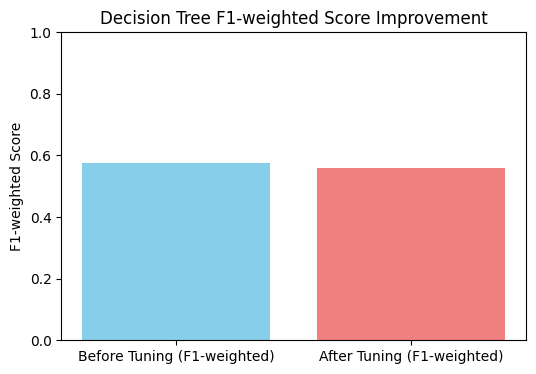

In [46]:
from sklearn.metrics import f1_score

f1_before = f1_score(y_test, y_pred, average='weighted')
f1_after = f1_score(y_test, y_pred_best, average='weighted')

plt.figure(figsize=(6,4))
plt.bar(['Before Tuning (F1-weighted)', 'After Tuning (F1-weighted)'], [f1_before, f1_after], color=['skyblue', 'lightcoral'])
plt.title("Decision Tree F1-weighted Score Improvement")
plt.ylabel("F1-weighted Score")
plt.ylim(0, 1) # F1 score is between 0 and 1
plt.show()

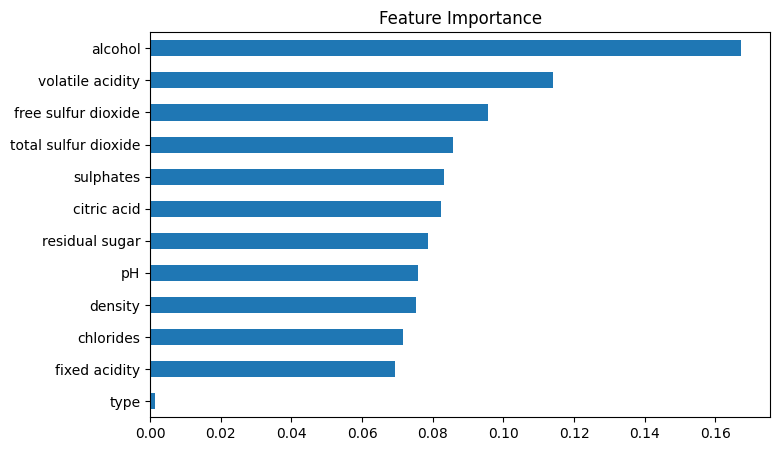

In [39]:
importance = pd.Series(best_dt.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

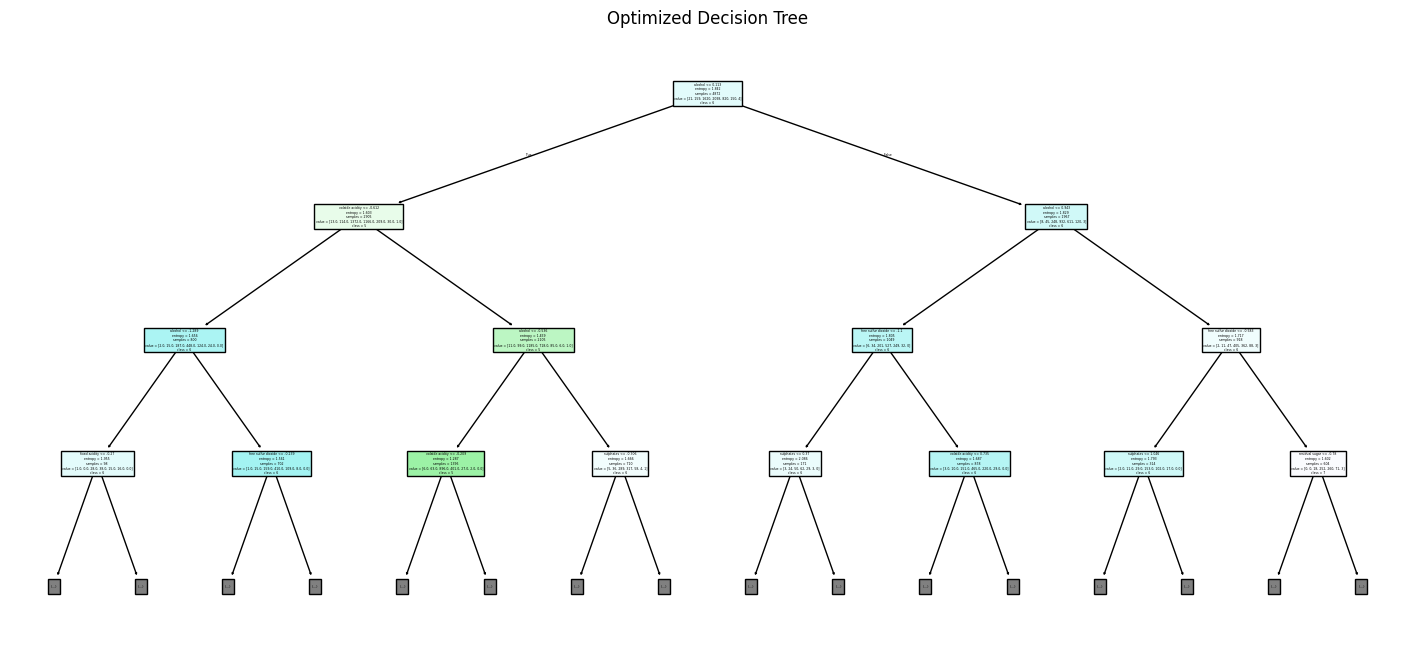

In [40]:
plt.figure(figsize=(18,8))

plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=[str(i) for i in sorted(y.unique())],
    filled=True,
    max_depth=3
)

plt.title("Optimized Decision Tree")
plt.show()